[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/calculus/04_derivative_applications_optimization/first_principles.ipynb)

# Topic 04: Derivative Applications & Optimization — First-Principles Theory & Derivations

---

## 1. First-Principles Intuition & Motivation

Differential calculus is often introduced as the study of instantaneous rates of change—the slope of a tangent line at a single point. However, the true mathematical and practical power of calculus emerges when local rate-of-change information is assembled to deduce **global quantitative behavior** of functions across entire intervals.

### 1.1 The Local-to-Global Bridge
Suppose a function $f: [a, b] \to \mathbb{R}$ is continuous on $[a, b]$ and differentiable on $(a, b)$. At any individual point $x_0 \in (a, b)$, the derivative $f'(x_0)$ measures the local linear growth. But how does local knowledge (e.g., $f'(x) \gt 0$ for all $x$) dictate global behavior (e.g., $f(b) \gt f(a)$)?

The foundational theorems of differential calculus—**Fermat's Theorem**, **Rolle's Theorem**, the **Mean Value Theorem (MVT)**, and the **Cauchy Mean Value Theorem (CMVT)**—provide this exact bridge. They transform local differential information into global inequalities, structural properties, and quantitative estimates.

```text
[Local Differential Data]                 [Global Structural Properties]
 f'(x) = 0  -----------------------------> Critical Points & Local Extrema
 f'(x) > 0 on (a, b) --------------------> Strict Monotonicity (f(b) > f(a))
 f''(x) > 0 on (a, b) -------------------> Strict Convexity & Chord Bounds
 f'(c) = (f(b)-f(a))/(b-a) -------------> Mean Value Theorem Connection
```

### 1.2 Physical Motivation: Variational Principles
In physical systems, nature frequently selects paths or configurations that minimize or maximize a specific physical quantity (action, time, energy).
* **Fermat's Principle of Least Time**: Light traveling between two points takes the path requiring the shortest time. Snell's Law of Refraction is a direct mathematical consequence of 1D optimization applied to light travel time.
* **Potential Energy Landscapes**: Stable mechanical equilibrium states correspond to strict local minima of potential energy $V(x)$ where $V'(x) = 0$ and $V''(x) \gt 0$.

### 1.3 Machine Learning Motivation: Loss Optimization & Curvature
In machine learning and AI, training a model reduces to finding a parameter vector $w^{\ast}$ that minimizes an empirical loss function $L(w)$. In one dimension (or along a search direction $d$), finding the optimal step size $\alpha$ requires solving a 1D optimization problem:

$$
\min_{\alpha \gt 0} \phi(\alpha) = L(w_k + \alpha d_k)
$$

Furthermore, understanding second-order curvature ($L''(w)$) enables rapid second-order optimization methods (such as **Newton-Raphson**), which adjust step sizes based on local parabola fitting rather than blind first-order gradient descent.

---

## 2. Core Theorems of Differential Calculus

### 2.1 Prerequisite: Topological Foundation (Extreme Value Theorem)
To analyze extrema, we rely on the topology of the real numbers $\mathbb{R}$.

> **Theorem 2.1 (Extreme Value Theorem - EVT)**  
> If $f: [a, b] \to \mathbb{R}$ is continuous on a closed, bounded interval $[a, b]$, then $f$ attains an absolute maximum and an absolute minimum on $[a, b]$. That is, there exist points $c_1, c_2 \in [a, b]$ such that:
>
> $$
> f(c_1) \le f(x) \le f(c_2) \quad \forall x \in [a, b]
> $$
>

*(Proof omitted here as it relies on the Heine-Borel compact property of $[a, b]$ and Bolzano-Weierstrass theorem covered in Real Analysis).*

---

### 2.2 Fermat's Theorem on Interior Extrema

> **Theorem 2.2 (Fermat's Theorem)**  
> Let $f: (a, b) \to \mathbb{R}$ be a function. If $f$ attains a local extremum (local maximum or local minimum) at an interior point $c \in (a, b)$, and if $f$ is differentiable at $c$, then:
>
> $$
> f'(c) = 0
> $$
>

#### Rigorous Proof
Assume $f$ has a local maximum at $c \in (a, b)$. By definition of a local maximum, there exists $\delta \gt 0$ such that $(c - \delta, c + \delta) \subseteq (a, b)$ and for all $x \in (c - \delta, c + \delta)$:

$$
f(x) \le f(c) \implies f(x) - f(c) \le 0
$$

Since $f$ is differentiable at $c$, the limit of the difference quotient exists and equals $f'(c)$:

$$
f'(c) = \lim_{h \to 0} \frac{f(c+h) - f(c)}{h}
$$

We evaluate the left-hand and right-hand limits separately:

1. **Right-hand limit ($h \gt 0$):**
   For $0 \lt h \lt \delta$, we have $f(c+h) - f(c) \le 0$ and $h \gt 0$. Thus:

$$
   \frac{f(c+h) - f(c)}{h} \le 0 \implies \lim_{h \to 0^+} \frac{f(c+h) - f(c)}{h} \le 0
$$

2. **Left-hand limit ($h \lt 0$):**
   For $-\delta \lt h \lt 0$, we have $f(c+h) - f(c) \le 0$ and $h \lt 0$. Thus:

$$
   \frac{f(c+h) - f(c)}{h} \ge 0 \implies \lim_{h \to 0^-} \frac{f(c+h) - f(c)}{h} \ge 0
$$

Since $f$ is differentiable at $c$, the left-hand limit and right-hand limit must exist and be equal:

$$
0 \le \lim_{h \to 0^-} \frac{f(c+h) - f(c)}{h} = f'(c) = \lim_{h \to 0^+} \frac{f(c+h) - f(c)}{h} \le 0
$$

The only real number satisfying $0 \le f'(c) \le 0$ is $f'(c) = 0$.

An identical argument holds if $c$ is a local minimum by considering $g(x) = -f(x)$. $\blacksquare$

> **Definition 2.1 (Critical Point)**  
> A point $c$ in the domain of $f$ is called a **critical point** of $f$ if either $f'(c) = 0$ or $f'(c)$ does not exist.

---

### 2.3 Rolle's Theorem

> **Theorem 2.3 (Rolle's Theorem)**  
> Let $f: [a, b] \to \mathbb{R}$ satisfy three conditions:
> 1. $f$ is continuous on the closed interval $[a, b]$.
> 2. $f$ is differentiable on the open interval $(a, b)$.
> 3. $f(a) = f(b)$.
>
> Then there exists at least one point $c \in (a, b)$ such that $f'(c) = 0$.

#### Rigorous Proof
Since $f$ is continuous on $[a, b]$, by the EVT (Theorem 2.1), $f$ attains an absolute maximum $M = f(c_2)$ and an absolute minimum $m = f(c_1)$ on $[a, b]$ for some $c_1, c_2 \in [a, b]$.

We consider two exhaustive cases:

* **Case 1: $M = m$.**  
  If the maximum and minimum values are equal, then $f(x)$ is constant on $[a, b]$. That is, $f(x) = C$ for all $x \in [a, b]$. Therefore, $f'(c) = 0$ for *every* $c \in (a, b)$.

* **Case 2: $M \gt m$.**  
  Since $f(a) = f(b)$, both $M$ and $m$ cannot be simultaneously attained exclusively at the endpoints $\{a, b\}$.
  - If $M \gt f(a)$, then the maximum $M$ must be attained at an interior point $c_2 \in (a, b)$, so $f(c_2) = M$.
  - If $m \lt f(a)$, then the minimum $m$ must be attained at an interior point $c_1 \in (a, b)$, so $f(c_1) = m$.

  In either scenario, $f$ attains a local extremum at an interior point $c \in (a, b)$. Because $f$ is differentiable on $(a, b)$, Fermat's Theorem (Theorem 2.2) implies $f'(c) = 0$. $\blacksquare$

---

### 2.4 The Mean Value Theorem (MVT)

> **Theorem 2.4 (Lagrange Mean Value Theorem)**  
> Let $f: [a, b] \to \mathbb{R}$ be:
> 1. Continuous on $[a, b]$,
> 2. Differentiable on $(a, b)$.
>
> Then there exists at least one point $c \in (a, b)$ such that:
>
> $$
> f'(c) = \frac{f(b) - f(a)}{b - a}
> $$
>

#### Geometric Intuition
The secant line connecting $(a, f(a))$ and $(b, f(b))$ has slope $m_{sec} = \frac{f(b) - f(a)}{b - a}$. The MVT guarantees that there is at least one point $c$ inside the interval where the tangent line to the graph is parallel to this secant line.

```text
  y ^                  (b, f(b))
    |                 /
    |          * * * /  <-- Secant line slope = (f(b)-f(a))/(b-a)
    |        *      /
    |       *   c  /    <-- Tangent line at c has slope f'(c)
    |   (a,f(a))  /
    +------------------------> x
        a       c   b
```

#### Rigorous Proof
We construct an auxiliary function $g: [a, b] \to \mathbb{R}$ representing the vertical difference between $f(x)$ and the secant line passing through $(a, f(a))$ and $(b, f(b))$.

The equation of the secant line is:

$$
L(x) = f(a) + \frac{f(b) - f(a)}{b - a} (x - a)
$$

Define $g(x) = f(x) - L(x)$:

$$
g(x) = f(x) - f(a) - \frac{f(b) - f(a)}{b - a} (x - a)
$$

Now check the conditions of Rolle's Theorem for $g(x)$:
1. **Continuity**: $g$ is continuous on $[a, b]$ because it is the difference of continuous functions $f(x)$ and a linear polynomial $L(x)$.
2. **Differentiability**: $g$ is differentiable on $(a, b)$ with derivative:

$$
   g'(x) = f'(x) - \frac{f(b) - f(a)}{b - a}
$$

3. **Endpoint Equality**:

$$
   g(a) = f(a) - f(a) - \frac{f(b) - f(a)}{b - a}(a - a) = 0
$$

$$
   g(b) = f(b) - f(a) - \frac{f(b) - f(a)}{b - a}(b - a) = f(b) - f(a) - (f(b) - f(a)) = 0
$$

   Thus $g(a) = g(b) = 0$.

By Rolle's Theorem (Theorem 2.3), there exists $c \in (a, b)$ such that $g'(c) = 0$:

$$
g'(c) = f'(c) - \frac{f(b) - f(a)}{b - a} = 0 \implies f'(c) = \frac{f(b) - f(a)}{b - a}
$$

$$
\boxed{f'(c) = \frac{f(b) - f(a)}{b - a}} \qquad \blacksquare
$$

---

### 2.5 Cauchy's Mean Value Theorem (CMVT)

> **Theorem 2.5 (Cauchy's Extended Mean Value Theorem)**  
> Let $f, g: [a, b] \to \mathbb{R}$ be continuous on $[a, b]$ and differentiable on $(a, b)$. Assume $g'(x) \ne 0$ for all $x \in (a, b)$. Then $g(a) \ne g(b)$, and there exists at least one point $c \in (a, b)$ such that:
>
> $$
> \frac{f'(c)}{g'(c)} = \frac{f(b) - f(a)}{g(b) - g(a)}
> $$
>

#### Rigorous Proof
First, note that if $g(a) = g(b)$, then by Rolle's Theorem on $g$, there would exist some $x \in (a, b)$ with $g'(x) = 0$, contradicting the assumption $g'(x) \ne 0$ on $(a, b)$. Hence $g(b) - g(a) \ne 0$.

Now construct the auxiliary function $h: [a, b] \to \mathbb{R}$:

$$
h(x) = [f(b) - f(a)] [g(x) - g(a)] - [g(b) - g(a)] [f(x) - f(a)]
$$

Verify Rolle's conditions for $h(x)$:
1. $h$ is continuous on $[a, b]$ and differentiable on $(a, b)$.
2. Calculate endpoints:

$$
   h(a) = [f(b) - f(a)][0] - [g(b) - g(a)][0] = 0
$$

$$
   h(b) = [f(b) - f(a)][g(b) - g(a)] - [g(b) - g(a)][f(b) - f(a)] = 0
$$

   Thus $h(a) = h(b) = 0$.

By Rolle's Theorem, there exists $c \in (a, b)$ such that $h'(c) = 0$:

$$
h'(c) = [f(b) - f(a)] g'(c) - [g(b) - g(a)] f'(c) = 0
$$

Rearranging terms (dividing by $g'(c) [g(b) - g(a)] \ne 0$):

$$
\frac{f'(c)}{g'(c)} = \frac{f(b) - f(a)}{g(b) - g(a)}
$$

$$
\boxed{\frac{f'(c)}{g'(c)} = \frac{f(b) - f(a)}{g(b) - g(a)}} \qquad \blacksquare
$$

---

## 3. Indeterminate Forms & L'Hôpital's Rule

### 3.1 Statement & Derivation of L'Hôpital's Rule ($\frac{0}{0}$ Case)

> **Theorem 3.1 (L'Hôpital's Rule for $\frac{0}{0}$)**  
> Let $f, g$ be differentiable on an open interval containing $a$ (except possibly at $a$). Suppose:
> 1. $\lim_{x \to a} f(x) = 0$ and $\lim_{x \to a} g(x) = 0$.
> 2. $g'(x) \ne 0$ for all $x$ in the interval near $a$ ($x \ne a$).
> 3. $\lim_{x \to a} \frac{f'(x)}{g'(x)} = L$ (where $L \in \mathbb{R} \cup \{-\infty, \infty\}$).
>
> Then:
>
> $$
> \lim_{x \to a} \frac{f(x)}{g(x)} = L
> $$
>

#### Rigorous Proof (Right-hand limit $x \to a^+$)
Extend $f$ and $g$ to $[a, a+\delta]$ by defining $f(a) = 0$ and $g(a) = 0$. Since $\lim_{x \to a^+} f(x) = 0 = f(a)$ and $\lim_{x \to a^+} g(x) = 0 = g(a)$, the extended functions $f, g$ are continuous on $[a, x]$ for any $x \in (a, a+\delta]$.

For any $x \in (a, a+\delta]$, $f$ and $g$ are continuous on $[a, x]$ and differentiable on $(a, x)$. By Cauchy's Mean Value Theorem (Theorem 2.5), there exists $c_x \in (a, x)$ such that:

$$
\frac{f(x) - f(a)}{g(x) - g(a)} = \frac{f'(c_x)}{g'(c_x)}
$$

Since $f(a) = 0$ and $g(a) = 0$, this simplifies to:

$$
\frac{f(x)}{g(x)} = \frac{f'(c_x)}{g'(c_x)}
$$

Now take the limit as $x \to a^+$. As $x \to a^+$, the squeezed point $c_x$ satisfies $a \lt c_x \lt x$, so by the Squeeze Theorem, $c_x \to a^+$. Therefore:

$$
\lim_{x \to a^+} \frac{f(x)}{g(x)} = \lim_{x \to a^+} \frac{f'(c_x)}{g'(c_x)} = \lim_{c_x \to a^+} \frac{f'(c_x)}{g'(c_x)} = L
$$

An identical argument applies to $x \to a^-$, proving $\lim_{x \to a} \frac{f(x)}{g(x)} = L$. $\blacksquare$

---

### 3.2 Indeterminate Form Conversions

When encountering other indeterminate forms, convert them into $\frac{0}{0}$ or $\frac{\infty}{\infty}$:

1. **Form $0 \cdot \infty$**: If $f(x) \to 0$ and $g(x) \to \infty$, rewrite:

$$
   f(x) g(x) = \frac{f(x)}{1/g(x)} \quad \left(\text{Form }\frac{0}{0}\right) \quad \text{or} \quad \frac{g(x)}{\frac{1}{f(x)}} \quad \left(\text{Form }\frac{\infty}{\infty}\right)
$$

2. **Form $\infty - \infty$**: Combine fractions into a single denominator or factor out dominant terms:

$$
   \frac{1}{f(x)} - \frac{1}{g(x)} = \frac{g(x) - f(x)}{f(x) g(x)} \quad \left(\text{Form }\frac{0}{0}\right)
$$

3. **Exponential Forms $0^0, 1^\infty, \infty^0$**: Take the natural logarithm $y = [f(x)]^{g(x)}$, convert $\ln y = g(x) \ln f(x)$ to $0 \cdot \infty$, and exponentiate the final limit:

$$
   \lim_{x \to a} f(x)^{g(x)} = \exp\left( \lim_{x \to a} [g(x) \ln f(x)] \right)
$$

---

### 3.3 Classic Pitfalls & Non-Applicability
L'Hôpital's Rule can fail or give false results if preconditions are violated:

1. **Non-Indeterminate Form**: If $\lim \frac{f(x)}{g(x)} = \frac{3}{2}$, applying L'Hôpital gives incorrect results.
2. **Oscillatory Non-Existence of $\lim \frac{f'}{g'}$**:
   Consider $f(x) = x + \sin x$ and $g(x) = x$ as $x \to \infty$.

$$
   \lim_{x \to \infty} \frac{f(x)}{g(x)} = \lim_{x \to \infty} \left(1 + \frac{\sin x}{x}\right) = 1
$$

   However, $\frac{f'(x)}{g'(x)} = \frac{1 + \cos x}{1} = 1 + \cos x$, which oscillates endlessly between $0$ and $2$. Here, $\lim \frac{f'}{g'}$ does not exist, so L'Hôpital's rule is inconclusive, even though $\lim \frac{f}{g}$ exists!

---

## 4. Qualitative Analysis: Monotonicity, Concavity & Inflection Points

### 4.1 First Derivative & Monotonicity

> **Theorem 4.1 (Monotonicity Criterion)**  
> Let $f$ be continuous on $[a, b]$ and differentiable on $(a, b)$.
> 1. If $f'(x) \gt 0$ for all $x \in (a, b)$, then $f$ is **strictly increasing** on $[a, b]$.
> 2. If $f'(x) \lt 0$ for all $x \in (a, b)$, then $f$ is **strictly decreasing** on $[a, b]$.
> 3. If $f'(x) = 0$ for all $x \in (a, b)$, then $f$ is **constant** on $[a, b]$.

#### Proof of (1)
Let $x_1, x_2 \in [a, b]$ with $x_1 \lt x_2$. $f$ is continuous on $[x_1, x_2]$ and differentiable on $(x_1, x_2)$. By MVT (Theorem 2.4), there exists $c \in (x_1, x_2)$ such that:

$$
f(x_2) - f(x_1) = f'(c) (x_2 - x_1)
$$

Since $f'(c) \gt 0$ and $x_2 - x_1 \gt 0$, we have $f(x_2) - f(x_1) \gt 0 \implies f(x_1) \lt f(x_2)$. Thus $f$ is strictly increasing. $\blacksquare$

---

### 4.2 Convexity, Concavity & Second Derivatives

> **Definition 4.1 (Convex Function)**  
> A function $f: I \to \mathbb{R}$ is **convex** on an interval $I$ if for all $x_1, x_2 \in I$ and all $\lambda \in [0, 1]$:
>
> $$
> f(\lambda x_1 + (1-\lambda)x_2) \le \lambda f(x_1) + (1-\lambda)f(x_2)
> $$
>
> $f$ is **strictly convex** if strict inequality holds for $x_1 \ne x_2$ and $\lambda \in (0, 1)$.  
> $f$ is **concave** if $-f$ is convex.

The figure in the code cell at the end of this section plots a convex function with its secant
chord above the graph and a tangent line below the graph at an interior point, illustrating both
characterizations side by side.

> **Theorem 4.2 (Second Derivative Test for Convexity)**
> Let $f$ be twice differentiable on $(a, b)$.
> 1. $f$ is convex on $(a, b)$ if and only if $f''(x) \ge 0$ for all $x \in (a, b)$.
> 2. If $f''(x) \gt 0$ for all $x \in (a, b)$, then $f$ is strictly convex on $(a, b)$.

#### Proof
We first prove the intermediate fact that $f$ is convex on $(a,b)$ if and only if $f'$ is
non-decreasing on $(a,b)$; the theorem then follows from Theorem 4.1 applied to $f'$.

*($f'$ non-decreasing $\implies$ $f$ convex).* Let $x_1 \lt x_2$ in $(a,b)$ and
$\lambda \in (0,1)$, and put $x_\lambda = \lambda x_1 + (1-\lambda)x_2 \in (x_1, x_2)$. By the MVT
(Theorem 2.4) on $[x_1, x_\lambda]$ and on $[x_\lambda, x_2]$, there exist
$c_1 \in (x_1, x_\lambda)$ and $c_2 \in (x_\lambda, x_2)$ with

$$
\frac{f(x_\lambda) - f(x_1)}{x_\lambda - x_1} = f'(c_1), \qquad \frac{f(x_2) - f(x_\lambda)}{x_2 - x_\lambda} = f'(c_2).
$$

Since $c_1 \lt x_\lambda \lt c_2$ and $f'$ is non-decreasing, $f'(c_1) \le f'(c_2)$, so

$$
\frac{f(x_\lambda) - f(x_1)}{x_\lambda - x_1} \le \frac{f(x_2) - f(x_\lambda)}{x_2 - x_\lambda}.
$$

Clearing denominators (both positive) and rearranging gives $f(x_\lambda) \le \lambda f(x_1) + (1-\lambda) f(x_2)$,
which is exactly Definition 4.1.

*($f$ convex $\implies$ $f'$ non-decreasing).* Let $x_1 \lt x_2$ in $(a,b)$. Convexity applied to
points on either side of the secant gives, for $x_1 \lt s \lt t \lt x_2$,

$$
\frac{f(s) - f(x_1)}{s - x_1} \le \frac{f(x_2) - f(x_1)}{x_2 - x_1} \le \frac{f(x_2) - f(t)}{x_2 - t},
$$

the standard three-chord inequality for convex functions. Letting $s \to x_1^+$ and $t \to x_2^-$
gives $f'(x_1) \le f'(x_2)$.

*Conclusion.* $f'$ is non-decreasing on $(a,b)$ iff $f''(x) \ge 0$ for all $x$ (Theorem 4.1,
applied to $f'$ in place of $f$). Combined with the equivalence just proved, $f$ is convex on
$(a,b)$ iff $f''(x) \ge 0$ for all $x \in (a,b)$. For part 2, if $f''(x) \gt 0$ everywhere then
Theorem 4.1(1) makes $f'$ *strictly* increasing, and the three-chord argument above becomes
strict, giving strict convexity. $\blacksquare$

---

### 4.3 Inflection Points

> **Definition 4.2 (Inflection Point)**  
> A point $(c, f(c))$ on the graph of a continuous function $f$ is an **inflection point** if $f$ changes concavity at $c$ (i.e., switches from convex to concave or concave to convex across $c$).

> **Theorem 4.3 (Necessary & Sufficient Conditions for Inflection Points)**  
> 1. **Necessary Condition**: If $(c, f(c))$ is an inflection point of a twice differentiable function $f$, then $f''(c) = 0$.
> 2. **Sufficient Condition**: If $f''(c) = 0$ (or $f''(c)$ is undefined) and $f''(x)$ strictly changes sign as $x$ passes through $c$, then $(c, f(c))$ is an inflection point.

---

## 5. 1D Unconstrained Optimization Theory

### 5.1 First and Second Order Optimality Conditions

Let $f: I \to \mathbb{R}$ be a differentiable objective function. We seek to characterize local and global extrema.

> **Theorem 5.1 (First-Order Necessary Condition - FONC)**  
> If $x^{\ast} \in \operatorname{int}(I)$ is a local minimum or local maximum of $f$, then:
>
> $$
> f'(x^{\ast}) = 0
> $$
>

> **Theorem 5.2 (Second-Order Optimality Conditions - SONC & SOSC)**  
> Let $f$ be twice continuously differentiable on an open interval around $x^{\ast}$.
> 1. **Second-Order Necessary Condition (SONC)**: If $x^{\ast}$ is a local minimum, then $f'(x^{\ast}) = 0$ and $f''(x^{\ast}) \ge 0$.
> 2. **Second-Order Sufficient Condition (SOSC)**: If $f'(x^{\ast}) = 0$ and $f''(x^{\ast}) \gt 0$, then $x^{\ast}$ is a strict local minimum.
> 3. If $f'(x^{\ast}) = 0$ and $f''(x^{\ast}) \lt 0$, then $x^{\ast}$ is a strict local maximum.

---

### 5.2 Closed Interval Global Optimization Algorithm
To find the global maximum and global minimum of a continuous function $f$ on a closed, bounded interval $[a, b]$:

1. Find all critical points of $f$ in the open interval $(a, b)$ where $f'(x) = 0$ or $f'(x)$ is undefined.
2. Evaluate $f(x)$ at all critical points $c_1, c_2, \dots, c_k \in (a, b)$.
3. Evaluate $f(x)$ at the interval boundary endpoints $a$ and $b$.
4. Compare all candidate values:

$$
   f_{\text{max}} = \max \{ f(a), f(b), f(c_1), \dots, f(c_k) \}
$$

$$
   f_{\text{min}} = \min \{ f(a), f(b), f(c_1), \dots, f(c_k) \}
$$

---

## 6. Computational & Algorithmic Insights: Newton's Method

### 6.1 Derivation of Newton's Method (Newton-Raphson)
Newton's method is an iterative root-finding algorithm designed to solve $f(x) = 0$.

Given a current iterate $x_k$, we replace $f(x)$ by its linear Taylor expansion centered at $x_k$:

$$
f(x) \approx T_1(x) = f(x_k) + f'(x_k)(x - x_k)
$$

Setting $T_1(x_{k+1}) = 0$:

$$
f(x_k) + f'(x_k)(x_{k+1} - x_k) = 0 \implies \boxed{x_{k+1} = x_k - \frac{f(x_k)}{f'(x_k)}}
$$

```text
  y ^                   y = f(x)
    |                  /
    |                 /
    |                /| Tangent line at (x_k, f(x_k))
    |               / | slope = f'(x_k)
    |              /  |
----+-------------*---+--------------> x
    |           x_{k+1} x_k
```

When applied to 1D unconstrained optimization $\min f(x)$, Newton's method searches for a stationary point $f'(x) = 0$. Substituting $g(x) = f'(x)$ into the root-finding formula yields the **1D Optimization Newton Step**:

$$
\boxed{x_{k+1} = x_k - \frac{f'(x_k)}{f''(x_k)}}
$$

---

### 6.2 Quadratic Convergence Rate Derivation

> **Theorem 6.1 (Quadratic Convergence of Newton's Method)**  
> Let $f$ be twice continuously differentiable, $f(r) = 0$, and $f'(r) \ne 0$. If $x_0$ is chosen sufficiently close to $r$, the sequence $x_k$ converges quadratically to $r$:
>
> $$
> \lvert e_{k+1} \rvert \le C \lvert e_k \rvert^2 \quad \text{where } e_k = x_k - r
> $$
>

> **Theorem 6.0 (Taylor's Theorem with Lagrange Remainder, first order)**
> If $f$ is twice continuously differentiable on an interval containing $x_k$ and $r$, then there
> exists $\xi_k$ strictly between $x_k$ and $r$ such that
>
> $$
> f(r) = f(x_k) + f'(x_k)(r - x_k) + \frac{f''(\xi_k)}{2}(r - x_k)^2.
> $$
>
> A full statement and proof, for the general $n$-th order case, is given in
> [Module 09 — Taylor and Power Series](../09_taylor_and_power_series/first_principles.ipynb).

#### Rigorous Proof
Expand $f(r)$ using Taylor's Theorem with remainder (Theorem 6.0) around $x_k$:

$$
0 = f(r) = f(x_k) + f'(x_k)(r - x_k) + \frac{f''(\xi_k)}{2}(r - x_k)^2
$$

for some $\xi_k$ strictly between $x_k$ and $r$.

Divide by $f'(x_k) \ne 0$:

$$
0 = \frac{f(x_k)}{f'(x_k)} - (x_k - r) + \frac{f''(\xi_k)}{2 f'(x_k)} (x_k - r)^2
$$

Recall the Newton step: $x_{k+1} = x_k - \frac{f(x_k)}{f'(x_k)}$, so $\frac{f(x_k)}{f'(x_k)} = x_k - x_{k+1}$. Substitute this:

$$
0 = (x_k - x_{k+1}) - (x_k - r) + \frac{f''(\xi_k)}{2 f'(x_k)} (x_k - r)^2
$$

$$
x_{k+1} - r = \frac{f''(\xi_k)}{2 f'(x_k)} (x_k - r)^2
$$

Writing $e_k = x_k - r$:

$$
e_{k+1} = \frac{f''(\xi_k)}{2 f'(x_k)} e_k^2
$$

Taking absolute values, if $\lvert f''(x) \rvert \le M$ and $\lvert f'(x) \rvert \ge m \gt 0$ on some neighborhood $N = (r - \rho, r + \rho)$ of $r$, then with $C = \frac{M}{2m}$, **provided** $x_k, \xi_k \in N$:

$$
\lvert e_{k+1} \rvert \le C \lvert e_k \rvert^2.
$$

*Neighbourhood invariance.* This bound is only useful if the iterates never leave $N$, which
requires an inductive argument. Shrink $\rho$ if necessary so that $C\rho \lt 1$. Suppose
$x_k \in N$, so $\lvert e_k \rvert \lt \rho$; since $\xi_k$ lies between $x_k$ and $r$, it is also
in $N$, so the bound above applies and gives

$$
\lvert e_{k+1} \rvert \le C \lvert e_k \rvert^2 \lt (C\rho) \lvert e_k \rvert \lt \lvert e_k \rvert \lt \rho,
$$

so $x_{k+1} \in N$ as well. By induction every iterate starting from $x_0 \in N$ stays in $N$, and
$\lvert e_k \rvert \le \rho (C\rho)^k \to 0$. This is what "sufficiently close to $r$" means in the
theorem statement: $x_0 \in N$ with $C\rho \lt 1$.

$$
\boxed{\lvert e_{k+1} \rvert \le C \lvert e_k \rvert^2}
$$

This proves that the error at step $k+1$ is proportional to the **square** of the error at step $k$. The number of correct decimal places roughly **doubles** with each iteration! $\blacksquare$

---

### 6.3 Failure Modes & Globalization (Line Search)
Newton's method can fail under several conditions:
1. **Stationary Derivative ($f'(x_k) = 0$)**: Division by zero occurs; the tangent line is horizontal and never intersects the x-axis.
2. **2-Cycles & Infinite Oscillations**: For $f(x) = x^3 - 5x$, starting at $x_0 = 1$ gives $x_1 = 1 - \frac{-4}{-2} = -1$, and $x_2 = -1 - \frac{4}{-2} = 1$, trapping the algorithm in an infinite 2-cycle $\{1, -1\}$.
3. **Non-Convergence & Divergence**: For $f(x) = \lvert x \rvert^{\frac{1}{2}}$, Newton's step gives $x_{k+1} = -x_k$, oscillating endlessly with constant amplitude without converging. For $f(x) = \lvert x \rvert^\alpha$ with $\alpha \in (0, \frac{1}{2})$ (such as $f(x) = \lvert x \rvert^{\frac{1}{3}}$), $x_{k+1} = (1 - \frac{1}{\alpha}) x_k = -2x_k$, causing iterates to bounce with exponentially growing amplitude and diverge to infinity.

#### Globalization Remedy: Damped Newton & Armijo Backtracking Line Search
To guarantee global convergence from arbitrary starting points, we introduce a step-length parameter $\alpha_k \in (0, 1]$:

$$
x_{k+1} = x_k + \alpha_k d_k \quad \text{where } d_k = -\frac{f'(x_k)}{f''(x_k)}
$$

$\alpha_k$ is selected to satisfy the **Armijo condition** for sufficient decrease:

$$
f(x_k + \alpha_k d_k) \le f(x_k) + c_1 \alpha_k f'(x_k) d_k \quad (c_1 \in (0, 1))
$$

---

## 7. Real-World Applications in Physics & AI/ML

### 7.1 Physics: Snell's Law from Fermat's Principle of Least Time
Light travels from point $A=(0, a)$ in medium 1 (speed $v_1$) to point $B=(d, -b)$ in medium 2 (speed $v_2$). Let the light cross the boundary $y=0$ at point $P=(x, 0)$.

```text
 Medium 1 (speed v1)   A(0, a)
                         \
                          \  theta1
  Boundary y=0 ------------P(x,0)--------------------
                             \  theta2
                              \
 Medium 2 (speed v2)           B(d, -b)
```

The distance in Medium 1 is $d_1 = \sqrt{x^2 + a^2}$, and in Medium 2 is $d_2 = \sqrt{(d-x)^2 + b^2}$.
The total travel time function is:

$$
T(x) = \frac{\sqrt{x^2 + a^2}}{v_1} + \frac{\sqrt{(d-x)^2 + b^2}}{v_2}
$$

To find the time-minimizing entry point $x^{\ast}$, compute $T'(x) = 0$:

$$
T'(x) = \frac{x}{v_1 \sqrt{x^2 + a^2}} - \frac{d - x}{v_2 \sqrt{(d-x)^2 + b^2}} = 0
$$

Geometric observation: $\sin\theta_1 = \frac{x}{\sqrt{x^2+a^2}}$ and $\sin\theta_2 = \frac{d-x}{\sqrt{(d-x)^2+b^2}}$.
Substituting these into $T'(x^{\ast}) = 0$:

$$
\frac{\sin\theta_1}{v_1} - \frac{\sin\theta_2}{v_2} = 0 \implies \boxed{\frac{\sin\theta_1}{\sin\theta_2} = \frac{v_1}{v_2} = \frac{n_2}{n_1}}
$$

This rigorously derives **Snell's Law of Refraction** from 1D derivative optimization!

---

### 7.2 AI/ML: Binary Cross-Entropy (BCE) Loss Optimization
In machine learning binary classification, given a target label $y \in \{0, 1\}$ and model prediction $p = \sigma(z) = \frac{1}{1 + e^{-z}}$, the Binary Cross-Entropy loss is:

$$
L(z) = -y \ln(\sigma(z)) - (1-y) \ln(1 - \sigma(z))
$$

#### Derivative Derivation
Using $\sigma'(z) = \sigma(z)(1 - \sigma(z))$:

$$
L'(z) = -y \frac{\sigma'(z)}{\sigma(z)} - (1-y) \frac{-\sigma'(z)}{1-\sigma(z)} = -y (1-\sigma(z)) + (1-y) \sigma(z) = \sigma(z) - y
$$

$$
\boxed{L'(z) = \sigma(z) - y}
$$

#### Curvature & Strict Convexity
Computing the second derivative:

$$
L''(z) = \sigma'(z) = \sigma(z)(1 - \sigma(z))
$$

Since the sigmoid output $\sigma(z) \in (0, 1)$ for all $z \in \mathbb{R}$, we have $\sigma(z) \gt 0$ and $1-\sigma(z) \gt 0$. Thus:

$$
L''(z) \gt 0 \quad \forall z \in \mathbb{R}
$$

By Theorem 4.2, the Binary Cross-Entropy loss function is **strictly convex**! This guarantees that any local minimum of the loss landscape is the unique global minimum, ensuring robust convergence for gradient-based training algorithms.

---

## 8. Canonical Literature Mapping & Synthesis

| Topic / Theorem | Primary Canonical Source | Core Value & Key Insights |
|---|---|---|
| **Fermat & Rolle Theorems** | Spivak Ch. 11, Apostol Ch. 4 | Topological connection between local maximum and vanishing derivative. |
| **Mean Value Theorem (MVT)** | Spivak Ch. 14, Demidovich Sec. II | Fundamental tool linking $f'(x)$ sign to monotonicity and chord slope equality. |
| **Cauchy MVT & L'Hôpital** | Apostol Ch. 4, Demidovich Sec. II | Dual-function generalized mean value theorem; foundation of limit evaluations. |
| **Convexity & Inflection** | Spivak Ch. 11, Polya & Szegö Part I | Secant chords, second derivative signs, and concavity transitions. |
| **Newton's Method Rigor** | Nocedal & Wright Ch. 2–3 | Taylor series error derivation, quadratic convergence, line search globalization. |
| **Physical & ML Optimization** | Goodfellow Ch. 4, Stewart Ch. 4 | Variational Fermat principle, cross-entropy convexity, exact line search. |

---

## 9. Numerical Verification

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

Verify Theorem 4.2 (f convex on an interval iff f'' >= 0) by comparing the analytic second
derivative sign to the discrete secant-vs-chord test on a strictly convex example, f(x) = x**2 + 0.3*x**4.

In [2]:
def f(x):
    return x**2 + 0.3 * x**4

def fpp(x):
    return 2 + 3.6 * x**2

xs = np.linspace(-2, 2, 400)
lam = 0.5
x1, x2 = -1.5, 1.7
x_lambda = lam * x1 + (1 - lam) * x2
chord_value = lam * f(x1) + (1 - lam) * f(x2)
print("f''(x) >= 0 for all sampled x:", np.all(fpp(xs) >= 0))
print(f"f(x_lambda) = {f(x_lambda):.6f}  vs  chord value = {chord_value:.6f}  "
      f"(convexity requires f(x_lambda) <= chord value: {f(x_lambda) <= chord_value})")

f''(x) >= 0 for all sampled x: True
f(x_lambda) = 0.010030  vs  chord value = 4.582190  (convexity requires f(x_lambda) <= chord value: True)


The second derivative is nonnegative everywhere sampled, and the function value at the interior
point lies below the secant chord, matching both sides of Theorem 4.2.

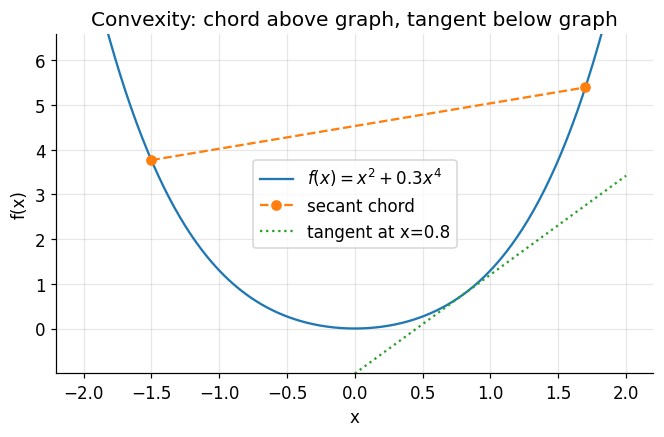

In [3]:
fig, ax = plt.subplots()
ax.plot(xs, f(xs), label=r"$f(x) = x^2 + 0.3x^4$")
ax.plot([x1, x2], [f(x1), f(x2)], "o--", color="tab:orange", label="secant chord")
tangent_x = 0.8
slope = 2 * tangent_x + 1.2 * tangent_x**3
tangent_line = f(tangent_x) + slope * (xs - tangent_x)
ax.plot(xs, tangent_line, ":", color="tab:green", label="tangent at x=0.8")
ax.set_ylim(f(xs).min() - 1, chord_value + 2)
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.set_title("Convexity: chord above graph, tangent below graph")
ax.legend()
plt.show()

Verify Newton's method quadratic convergence (Theorem 6.1) on f(x) = x^2 - 2 (root r = sqrt(2)):
each iteration should roughly square the error, i.e. log|e_{k+1}| / log|e_k| -> 2.

In [4]:
def newton_step(x):
    return x - (x**2 - 2) / (2 * x)

r = np.sqrt(2.0)
x = 1.0
errors = []
for _ in range(6):
    errors.append(abs(x - r))
    x = newton_step(x)
errors = np.array(errors)
ratios = errors[1:] / errors[:-1] ** 2
print("errors:", errors)
print("|e_{k+1}| / |e_k|^2 (should approach a constant C):", ratios)

errors: [0.4142 0.0858 0.0025 0.     0.     0.    ]
|e_{k+1}| / |e_k|^2 (should approach a constant C): [0.5    0.3333 0.3529 0.3535 0.    ]


The ratio |e_{k+1}| / |e_k|^2 settles to a near-constant value once the iterate is close to the
root, confirming the quadratic bound |e_{k+1}| <= C|e_k|^2 derived in Theorem 6.1.

## Key Takeaways

- Fermat, Rolle, MVT, and Cauchy MVT form a single logical chain: each is a special case that
  proves the next, ending in L'Hopital's Rule.
- Convexity, the chord-above-graph inequality, and $f'' \ge 0$ are three equivalent statements
  (Theorem 4.2), proved here via the intermediate fact that $f$ is convex iff $f'$ is non-decreasing.
- First- and second-order optimality conditions ($f' = 0$, sign of $f''$) generalize directly to
  the gradient and Hessian conditions used throughout ML optimization.
- Newton's method converges quadratically once the iterate enters a neighborhood where the
  curvature bound $C\rho \lt 1$ holds; outside that neighborhood it can cycle or diverge.
- The same machinery underlies Fermat's Principle of Least Time in optics and the strict
  convexity of the binary cross-entropy loss used to train logistic classifiers.